## Final Project Submission

Please fill out:
* Student name: John Kundycki
* Student pace: Full Time
* Scheduled project review date/time: 
* Instructor name: Rafael Carrasco
* Blog post URL:


# Preparing the Notebook to answer Questions

In [1]:
#Import libraries that may be used
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot
import sqlite3
from importlib import reload
from datetime import datetime
%matplotlib inline

In [2]:
#Read the relevant csv files
movie_gross = pd.read_csv('bom.movie_gross.csv')
imdb_name = pd.read_csv('imdb.name.basics.csv')
title_akas = pd.read_csv('title.akas.csv')
title_basics = pd.read_csv('title.basics.csv')
title_crew = pd.read_csv('title.crew.csv')
title_principals = pd.read_csv('title.principals.csv')
title_ratings = pd.read_csv('title.ratings.csv')
tmdb_movies = pd.read_csv('tmdb.movies.csv')
movie_budgets = pd.read_csv('tn.movie_budgets.csv')

In [3]:
#Preparing SQL by connecting to the sqlite file, connecting cursor and preparing functions to manipulate the tables
conn = sqlite3.connect('movies_db.sqlite')
cur = conn.cursor()

def get_table_list(conn):
    query = "select name from sqlite_master where type='table';"
    table_names = [r[0] for r in conn.execute(query).fetchall()]
    return table_names


def load_table(conn, table_name):
    query = f"select * from {table_name}"
    df = pd.read_sql(query, conn)
    return df

def preview_tables(conn, tables='all'):
    all_tables = get_table_list(conn)
    if tables=='all':
        final_table_names = all_tables
        
    elif type(tables) == list:
        final_table_names = [t for t in all_tables if t in tables]
    
    for table_name in final_table_names:
        print(f"Showing Table: {table_name}")
        query = f"select * from {table_name};"
        df = pd.read_sql(query, conn)
        display(df.head(2))
        print("-"*100)
    print("finished")
    return None

In [4]:
#Get the list of tables by name as reference so they can be accessed
table_names = get_table_list(conn)
table_names

['bom_movie_gross',
 'imdb_name_basics',
 'title_akas',
 'title_basics',
 'title_crew',
 'title_principals',
 'title_ratings',
 'tmdb_movies',
 'tn_movie_budgets']

# Question 1: Are there any noticeable trends in the data in terms of profit and profitability?

In [5]:
#Clean the data to remove all duplicates
movie_budgets.drop_duplicates(subset='movie',keep='first',inplace=True)

In [6]:
#Removing $ and , symbol from relevant columns
movie_budgets['domestic_gross'] = movie_budgets['domestic_gross'].str.replace(',', '').str.replace('$', '')
movie_budgets['production_budget'] = movie_budgets['production_budget'].str.replace(',', '').str.replace('$', '')
movie_budgets['worldwide_gross'] = movie_budgets['worldwide_gross'].str.replace(',', '').str.replace('$', '')

In [7]:
#Convert the pecuniary strings to integers
movie_budgets['domestic_gross'] = pd.to_numeric(movie_budgets['domestic_gross'])
movie_budgets['production_budget'] = pd.to_numeric(movie_budgets['production_budget'])
movie_budgets['worldwide_gross'] = pd.to_numeric(movie_budgets['worldwide_gross'])

In [8]:
#Create a new column profit (worldwidegross - production budget)
movie_budgets['profit'] = movie_budgets['worldwide_gross'] - movie_budgets['production_budget']

In [9]:
#Create a new column for profit ratio
movie_budgets['profit_margin'] = (movie_budgets['worldwide_gross'] - movie_budgets['production_budget'])/(movie_budgets['worldwide_gross'])

In [10]:
movie_budgets['profit_percentage'] = ((movie_budgets['profit']/movie_budgets['production_budget'])*100)

In [11]:
#Create dictionaries for the movie and profit columns and then the movie and profit_margin column
profit_dict = pd.Series(movie_budgets.profit.values,index=movie_budgets.movie).to_dict()
profitp_dict = pd.Series(movie_budgets.profit_percentage.values,index=movie_budgets.movie).to_dict()

In [12]:
#Make lists of the top 25 movies for both profit and profit margin
profit_list = list(profit_dict.items())
top_25profit = sorted(profit_list, key = lambda x: x[1], reverse=True)[:25]
profitp_list = list(profitp_dict.items())
top_25profitp = sorted(profitp_list, key = lambda x: x[1], reverse=True)[:25]

#Lists for top 50 to use later
top_50profit = movie_budgets.sort_values(by=['profit'], ascending=False)['movie'][:50]
top_50profitp = movie_budgets.sort_values(by=['profit_percentage'], ascending=False)['movie'][:50]
top_500profitp = movie_budgets.sort_values(by=['profit_percentage'], ascending=False)['movie'][:500]

In [13]:
#Make dependent and indepedent values so that they can be plotted for profits
x_prof = [i[1] for i in top_25profit]
y_prof = [i[0] for i in top_25profit]
x_perc = [i[1] for i in top_25profitp]
y_perc = [i[0] for i in top_25profitp]

[Text(0.5, 0, 'Profit in Billions of Dollars'),
 Text(0.5, 1.0, '25 Most Profitable Movies')]

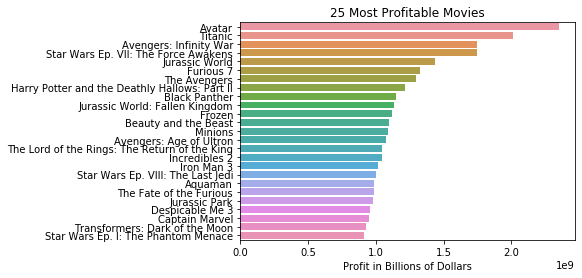

In [14]:
#Visualize the 25 most profitable movies
profplot = sns.barplot(x_prof, y_prof)
profplot.set(xlabel = 'Profit in Billions of Dollars',title='25 Most Profitable Movies')

[Text(0.5, 0, 'Profit Percentage'),
 Text(0.5, 1.0, '25 Movies with the Best Profit Percentage')]

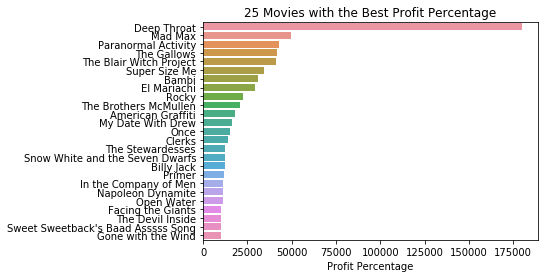

In [15]:
#Visualize the 25 movies with the best profit margins
profplotp = sns.barplot(x_perc, y_perc)
profplotp.set(xlabel = 'Profit Percentage',title='25 Movies with the Best Profit Percentage')

Deep Throat is clearly an outlier, let's take a look at the table without it.

[Text(0.5, 0, 'Profit Percentage'),
 Text(0.5, 1.0, '25 Movies with the Best Profit Percentage')]

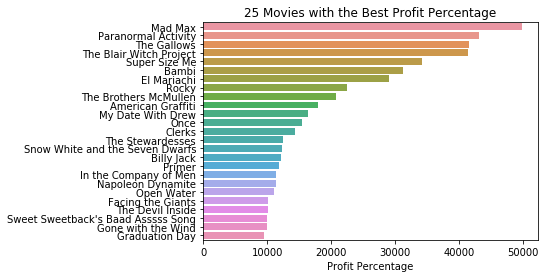

In [16]:
top_25profitpn = sorted(profitp_list, key = lambda x: x[1], reverse=True)[1:26]
x_percn = [i[1] for i in top_25profitpn]
y_percn = [i[0] for i in top_25profitpn]
profplotpn = sns.barplot(x_percn, y_percn)
profplotpn.set(xlabel = 'Profit Percentage',title='25 Movies with the Best Profit Percentage')

Much better!

In [17]:
mbprof = movie_budgets.sort_values(by=['profit'], ascending=False)
mbprof.head(50)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit,profit_margin,profit_percentage
0,1,"Dec 18, 2009",Avatar,425000000,760507625,2776345279,2351345279,0.846921,553.257713
42,43,"Dec 19, 1997",Titanic,200000000,659363944,2208208395,2008208395,0.909429,1004.104198
6,7,"Apr 27, 2018",Avengers: Infinity War,300000000,678815482,2048134200,1748134200,0.853525,582.711400
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,306000000,936662225,2053311220,1747311220,0.850972,571.016739
33,34,"Jun 12, 2015",Jurassic World,215000000,652270625,1648854864,1433854864,0.869606,666.909239
66,67,"Apr 3, 2015",Furious 7,190000000,353007020,1518722794,1328722794,0.874895,699.327786
26,27,"May 4, 2012",The Avengers,225000000,623279547,1517935897,1292935897,0.851772,574.638176
260,61,"Jul 15, 2011",Harry Potter and the Deathly Hallows: Part II,125000000,381193157,1341693157,1216693157,0.906834,973.354526
41,42,"Feb 16, 2018",Black Panther,200000000,700059566,1348258224,1148258224,0.851660,574.129112
112,13,"Jun 22, 2018",Jurassic World: Fallen Kingdom,170000000,417719760,1305772799,1135772799,0.869809,668.101646


Of the top 50 most profitable, only Avatar, Titanic, Frozen, The Lion King, Zootopia, Harry Potter and the Sorcerer's Stone, Finding Nemo, Bohemian Rhapsody, The Secret Life of Pets, Jurassic Park and ET are novel concepts (22% or 11/50) meaning 78% of the most profitable movies are sequels, prequels or remakes of the originals.

Even then, of the novel concepts, Frozen, Zootopia, Finding Nemo, The Secret Life of Pets, The Lion King
are all built upon well established, extremely succesful movie franchises and movie studios famous for their animation and past movies.

This leaves us with 12% (6/50) of the 50 most profitable movies coming from truly novel, standalone concepts. Some would argue that even these remaining 6 movies are not novel concepts. But for this analysis, we will consider them in the novel concept category as they hadn't been previously established in the film industry.

88% of the 50 most profitable movies have been built on the shoulders of already established giants.

In [18]:
mbprofm = movie_budgets.sort_values(by=['profit_margin'], ascending=False)
mbprofm.head(50)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit,profit_margin,profit_percentage
5745,46,"Jun 30, 1972",Deep Throat,25000,45000000,45000000,44975000,0.999444,179900.000000
5613,14,"Mar 21, 1980",Mad Max,200000,8750000,99750000,99550000,0.997995,49775.000000
5492,93,"Sep 25, 2009",Paranormal Activity,450000,107918810,194183034,193733034,0.997683,43051.785333
5679,80,"Jul 10, 2015",The Gallows,100000,22764410,41656474,41556474,0.997599,41556.474000
5406,7,"Jul 14, 1999",The Blair Witch Project,600000,140539099,248300000,247700000,0.997584,41283.333333
5709,10,"May 7, 2004",Super Size Me,65000,11529368,22233808,22168808,0.997077,34105.858462
5346,47,"Aug 13, 1942",Bambi,858000,102797000,268000000,267142000,0.996799,31135.431235
5773,74,"Feb 26, 1993",El Mariachi,7000,2040920,2041928,2034928,0.996572,29070.400000
5210,11,"Nov 21, 1976",Rocky,1000000,117235147,225000000,224000000,0.995556,22400.000000
5715,16,"Aug 9, 1995",The Brothers McMullen,50000,10426506,10426506,10376506,0.995205,20753.012000


98% of the movies with the highest profit margin are novel concepts (Paranormal Activity 2 is the only sequel).

From the trends shown above, my recommendation would be to purchase a well established franchise and create upon them for the largest dollar amount returns.
My next recommendation would be to start creating a novel concept to transform into a movie because starting from scratch has the best return on investment (highest profit margin).

# Question 2: Assuming we were to start a brand new movie from scratch, are there any trends that seem to help a movie get recognized if we started from scratch? Let's start by investigating if there are any trends for genre:

In [19]:
#Join the movie_budgets with the table with genres, title_basics, so 
#that we have a combined table with the info we want
query = """SELECT tn.*, imdb.genres
           FROM tn_movie_budgets as tn
           LEFT JOIN title_basics as imdb
           ON tn.movie = imdb.primary_title"""

joined_df = pd.read_sql(query, conn)
print(joined_df.shape)
joined_df.head()

(7221, 7)


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279",Horror
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875","Action,Adventure,Fantasy"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350","Action,Adventure,Sci-Fi"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963","Action,Adventure,Sci-Fi"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None


In [20]:
#Clean the data to remove all duplicates
joined_df.drop_duplicates(subset='movie',keep='first',inplace=True)

In [21]:
#Check the the shape and head of the new dataframe
print(joined_df.shape)
joined_df.head()

(5698, 7)


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279",Horror
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875","Action,Adventure,Fantasy"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350","Action,Adventure,Sci-Fi"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963","Action,Adventure,Sci-Fi"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None


In [22]:
#Preview how many rows in the dataframe have None as the genre type, leaving us with roughly half of the titles...
joined_df[joined_df['genres']!=joined_df['genres']]

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None
5,6,"Dec 18, 2015",Star Wars Ep. VII: The Force Awakens,"$306,000,000","$936,662,225","$2,053,311,220",None
7,8,"May 24, 2007",Pirates of the Caribbean: At Worldâs End,"$300,000,000","$309,420,425","$963,420,425",None
15,16,"May 4, 2007",Spider-Man 3,"$258,000,000","$336,530,303","$894,860,230",None
19,20,"Jul 15, 2009",Harry Potter and the Half-Blood Prince,"$250,000,000","$302,089,278","$935,213,767",None
...,...,...,...,...,...,...,...
7214,76,"May 26, 2006",Cavite,"$7,000","$70,071","$71,644",None
7215,77,"Dec 31, 2004",The Mongol King,"$7,000",$900,$900,None
7217,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495",None
7218,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338",None


In [23]:
#Turn genres into lists
joined_df['genres'] = joined_df['genres'].apply(lambda x: x.split(",") if x else x)
joined_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279",[Horror]
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875","[Action, Adventure, Fantasy]"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350","[Action, Adventure, Sci-Fi]"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963","[Action, Adventure, Sci-Fi]"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None


In [24]:
#Create a set that updates with the genres of the movies from the dataframe
all_genres = set()
for genres in joined_df['genres']:
    if genres:
        all_genres.update(genres)

In [25]:
#Make sure the list updated properly
all_genres

{'Action',
 'Adventure',
 'Animation',
 'Biography',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Musical',
 'Mystery',
 'News',
 'Romance',
 'Sci-Fi',
 'Sport',
 'Thriller',
 'War',
 'Western'}

In [26]:
#Make columns for each genre with a value of 0 for each row in our dataframe
for genre in all_genres:
    joined_df[genre] = np.zeros(shape=joined_df.shape[0])
                                
joined_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres,Western,Drama,Musical,...,History,Music,Comedy,Mystery,Crime,Fantasy,War,Action,Romance,Documentary
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279",[Horror],0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875","[Action, Adventure, Fantasy]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350","[Action, Adventure, Sci-Fi]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963","[Action, Adventure, Sci-Fi]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
#Iterate through the movies and update the genre columns to 1 if the movie contains that genre
for index, row in joined_df.iterrows():
    if row['genres']:
        for genre in row['genres']:
            joined_df.loc[index, genre] = 1

joined_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres,Western,Drama,Musical,...,History,Music,Comedy,Mystery,Crime,Fantasy,War,Action,Romance,Documentary
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279",[Horror],0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875","[Action, Adventure, Fantasy]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350","[Action, Adventure, Sci-Fi]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963","[Action, Adventure, Sci-Fi]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
#Convert the genres set to a list
all_genres = list(all_genres)
all_genres

['Western',
 'Drama',
 'Musical',
 'Thriller',
 'News',
 'Family',
 'Animation',
 'Sci-Fi',
 'Sport',
 'Biography',
 'Horror',
 'Adventure',
 'History',
 'Music',
 'Comedy',
 'Mystery',
 'Crime',
 'Fantasy',
 'War',
 'Action',
 'Romance',
 'Documentary']

In [29]:
#Create a dictionary that uses the genres as keys and adds the count to the keys for each hit through the
#top 50 profit margin movies
genre_count = {}
for movie in top_50profitp:
    movie_genres = joined_df[joined_df['movie']==movie]['genres'].values[0]
    try:
        for genre in movie_genres:
            genre_count[genre] = genre_count.get(genre, 0) + 1
    except:
        genre_count['not_listed'] = genre_count.get('not_listed', 0) + 1

genre_count

{'not_listed': 39,
 'Horror': 5,
 'Mystery': 3,
 'Thriller': 4,
 'Biography': 1,
 'Documentary': 1,
 'Action': 2,
 'Comedy': 1,
 'Drama': 3,
 'Animation': 1,
 'Family': 2,
 'Crime': 1,
 'Sport': 1}

In [30]:
#Unfortunately, the top 50 did not yield many data points, use the top 500 profit margin movies for more data points
genre_count = {}
for movie in top_500profitp:
    movie_genres = joined_df[joined_df['movie']==movie]['genres'].values[0]
    try:
        for genre in movie_genres:
            genre_count[genre] = genre_count.get(genre, 0) + 1
    except:
        genre_count['not_listed'] = genre_count.get('not_listed', 0) + 1

genre_count

{'not_listed': 319,
 'Horror': 44,
 'Mystery': 25,
 'Thriller': 30,
 'Biography': 16,
 'Documentary': 16,
 'Action': 32,
 'Comedy': 60,
 'Drama': 90,
 'Animation': 10,
 'Family': 7,
 'Crime': 10,
 'Sport': 2,
 'Fantasy': 9,
 'Romance': 23,
 'War': 2,
 'Music': 8,
 'Sci-Fi': 11,
 'Adventure': 21,
 'History': 2}

In [31]:
#Still a lot of movies with the genre as not_listed
genre_top_count_df = pd.DataFrame([genre_count])
genre_top_count_df.head(1)

,not_listed,Horror,Mystery,Thriller,Biography,Documentary,Action,Comedy,Drama,Animation,Family,Crime,Sport,Fantasy,Romance,War,Music,Sci-Fi,Adventure,History
0,319,44,25,30,16,16,32,60,90,10,7,10,2,9,23,2,8,11,21,2


In [32]:
#Converting the genre_counts to a list so it can be sorted
genre_counts = list(genre_count.items())

In [33]:
#Sorting the list
genre_sorted = sorted(genre_counts, key = lambda x: x[1], reverse=True)
genre_sorted

[('not_listed', 319),
 ('Drama', 90),
 ('Comedy', 60),
 ('Horror', 44),
 ('Action', 32),
 ('Thriller', 30),
 ('Mystery', 25),
 ('Romance', 23),
 ('Adventure', 21),
 ('Biography', 16),
 ('Documentary', 16),
 ('Sci-Fi', 11),
 ('Animation', 10),
 ('Crime', 10),
 ('Fantasy', 9),
 ('Music', 8),
 ('Family', 7),
 ('Sport', 2),
 ('War', 2),
 ('History', 2)]

In [34]:
#Create lists for each of the genres and the counts from the dictionary so that the data can be visualized
x = [item[1] for item in genre_sorted]
y = [item[0] for item in genre_sorted]

[Text(0.5, 0, 'Genre Counts'),
 Text(0.5, 1.0, 'Genre Counts for 500 Movies with Highest Profit Margin')]

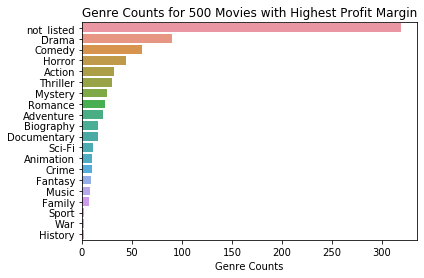

In [35]:
#Visualize the list of genres and counts
sns.gc = sns.barplot(x, y)
sns.gc.set(xlabel = 'Genre Counts',title='Genre Counts for 500 Movies with Highest Profit Margin')

In [36]:
#Too many data points in the not_listed column. Remove it to get a better visualization
genre_count = {}
for movie in top_500profitp:
    movie_genres = joined_df[joined_df['movie']==movie]['genres'].values[0]
    try:
        for genre in movie_genres:
            genre_count[genre] = genre_count.get(genre, 0) + 1
    except:
        pass

genre_count

{'Horror': 44,
 'Mystery': 25,
 'Thriller': 30,
 'Biography': 16,
 'Documentary': 16,
 'Action': 32,
 'Comedy': 60,
 'Drama': 90,
 'Animation': 10,
 'Family': 7,
 'Crime': 10,
 'Sport': 2,
 'Fantasy': 9,
 'Romance': 23,
 'War': 2,
 'Music': 8,
 'Sci-Fi': 11,
 'Adventure': 21,
 'History': 2}

In [37]:
#Set the genres and counts to a list again
genre_counts = list(genre_count.items())

In [38]:
#Sort the list
genre_sorted = sorted(genre_counts, key = lambda x: x[1], reverse=True)
genre_sorted

[('Drama', 90),
 ('Comedy', 60),
 ('Horror', 44),
 ('Action', 32),
 ('Thriller', 30),
 ('Mystery', 25),
 ('Romance', 23),
 ('Adventure', 21),
 ('Biography', 16),
 ('Documentary', 16),
 ('Sci-Fi', 11),
 ('Animation', 10),
 ('Crime', 10),
 ('Fantasy', 9),
 ('Music', 8),
 ('Family', 7),
 ('Sport', 2),
 ('War', 2),
 ('History', 2)]

In [39]:
#Create lists for each of the genres and the counts from the dictionary so that we can visualize the data
x = [item[1] for item in genre_sorted]
y = [item[0] for item in genre_sorted]

[Text(0.5, 0, 'Genre Counts'),
 Text(0.5, 1.0, 'Genre Counts for 500 Movies with Highest Profit Margin')]

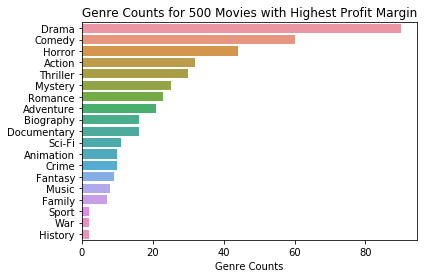

In [40]:
#Visualize the list of genres and counts now that not_listed is no longer included
sns.gc2 = sns.barplot(x, y)
sns.gc2.set(xlabel = 'Genre Counts',title='Genre Counts for 500 Movies with Highest Profit Margin')

Despite the unfortunate lack of genre for many of the titles, this graph contains enough data points to provide us with enough information as to what genres tend to have the highest profit margin. The three highest are Drama, Comedy and Horror in order. So my recommendation would be, if you are starting a new movie from scratch and want the highest profit margin, the movie should include Drama, Comedy or Horror as one of it's genres.

# Question 3: Is there a trend for the highest profit margin movies release month based on genre? Let's take a look at the top 8 profit margin genres:

I'm choosing the top 8 genres not only because they are the most represented genres in terms of profit margin, but also because the amount of data points starts to fall off heavily, making the data less interesting and relevant.

In [41]:
#Create a new column month from the first three characters of the release date
joined_df['month'] = joined_df['release_date'].str[:3]
joined_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres,Western,Drama,Musical,...,Music,Comedy,Mystery,Crime,Fantasy,War,Action,Romance,Documentary,month
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279",[Horror],0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Dec
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875","[Action, Adventure, Fantasy]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,May
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350","[Action, Adventure, Sci-Fi]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Jun
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963","[Action, Adventure, Sci-Fi]",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,May
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747",None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Dec


In [42]:
#Remove , and $ from relevant columns and convert to integers to make a profit margin column for joined df
joined_df['production_budget'] = joined_df['production_budget'].str.replace(',', '').str.replace('$', '')
joined_df['worldwide_gross'] = joined_df['worldwide_gross'].str.replace(',', '').str.replace('$', '')
joined_df['production_budget'] = pd.to_numeric(joined_df['production_budget'])
joined_df['worldwide_gross'] = pd.to_numeric(joined_df['worldwide_gross'])

In [43]:
#Create profit margin column
joined_df['profit_margin'] = (joined_df['worldwide_gross'] - joined_df['production_budget'])/(joined_df['worldwide_gross'])

In [44]:
#Find the lowest profit margin of the top 500
profit_margin_sorted = joined_df.sort_values(by=['profit_margin'], ascending=False)
profit_margin_sorted.head(500)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres,Western,Drama,Musical,...,Comedy,Mystery,Crime,Fantasy,War,Action,Romance,Documentary,month,profit_margin
7179,46,"Jun 30, 1972",Deep Throat,25000,"$45,000,000",45000000,None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Jun,0.999444
7023,14,"Mar 21, 1980",Mad Max,200000,"$8,750,000",99750000,None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Mar,0.997995
6872,93,"Sep 25, 2009",Paranormal Activity,450000,"$107,918,810",194183034,None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sep,0.997683
7102,80,"Jul 10, 2015",The Gallows,100000,"$22,764,410",41656474,"[Horror, Mystery, Thriller]",0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Jul,0.997599
6731,7,"Jul 14, 1999",The Blair Witch Project,600000,"$140,539,099",248300000,None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Jul,0.997584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2216,25,"Dec 18, 1985",Out of Africa,31000000,"$79,096,868",258210860,None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Dec,0.879943
6102,97,"Mar 9, 2012",Silent House,2000000,"$12,739,737",16610760,"[Drama, Horror, Mystery]",0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Mar,0.879596
7058,43,"Sep 23, 2011",Weekend,190000,"$484,592",1577585,"[Action, Comedy, Crime]",0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,Sep,0.879563
1680,85,"Nov 22, 1989",Back to the Future Part II,40000000,"$118,450,002",332000000,None,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Nov,0.879518


Nueve Reinas is the lowest in our top 500 profit margin with a profit margin of 0.879158.

In [45]:
#Iterate through the top 500 profit margin movies by specifying genre and having profit margin greater than or equal to the
#smallest profit margin value in the top 500 profit margin movies
top500horror = joined_df.loc[(joined_df['Horror'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500drama = joined_df.loc[(joined_df['Drama'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500comedy = joined_df.loc[(joined_df['Comedy'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500thriller = joined_df.loc[(joined_df['Thriller'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500action = joined_df.loc[(joined_df['Action'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500mystery = joined_df.loc[(joined_df['Mystery'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500romance = joined_df.loc[(joined_df['Romance'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500adventure = joined_df.loc[(joined_df['Adventure'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500bio = joined_df.loc[(joined_df['Biography'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500doc = joined_df.loc[(joined_df['Documentary'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500fantasy = joined_df.loc[(joined_df['Fantasy'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500anim = joined_df.loc[(joined_df['Animation'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500fam = joined_df.loc[(joined_df['Family'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500crime = joined_df.loc[(joined_df['Crime'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500scifi = joined_df.loc[(joined_df['Sci-Fi'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500music = joined_df.loc[(joined_df['Music'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500history = joined_df.loc[(joined_df['History'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500war = joined_df.loc[(joined_df['War'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']
top500sport = joined_df.loc[(joined_df['Sport'] == 1)  & (joined_df['profit_margin'] >= 0.879158)]['month']

Get the counts for each month for each of the 8 genres and then put them into terms so that they can be visualized:

In [46]:
horror_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500horror:
    horror_counts[month] = horror_counts.get(month, 0) + 1
horror_count = list(horror_counts.items())
hy = [item[1] for item in horror_count]
hx = [item[0] for item in horror_count]

In [47]:
drama_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500drama:
    drama_counts[month] = drama_counts.get(month, 0) + 1
drama_count = list(drama_counts.items())
dy = [item[1] for item in drama_count]
dx = [item[0] for item in drama_count]

In [48]:
comedy_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500comedy:
    comedy_counts[month] = comedy_counts.get(month, 0) + 1
comedy_count = list(comedy_counts.items())
cy = [item[1] for item in comedy_count]
cx = [item[0] for item in comedy_count]

In [49]:
thriller_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500thriller:
    thriller_counts[month] = thriller_counts.get(month, 0) + 1
thriller_count = list(thriller_counts.items())
ty = [item[1] for item in thriller_count]
tx = [item[0] for item in thriller_count]

In [50]:
action_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500action:
    action_counts[month] = action_counts.get(month, 0) + 1
action_count = list(action_counts.items())
ay = [item[1] for item in action_count]
ax = [item[0] for item in action_count]

In [51]:
mystery_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500mystery:
    mystery_counts[month] = mystery_counts.get(month, 0) + 1
mystery_count = list(mystery_counts.items())
my = [item[1] for item in mystery_count]
mx = [item[0] for item in mystery_count]

In [52]:
romance_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500romance:
    romance_counts[month] = romance_counts.get(month, 0) + 1
romance_count = list(romance_counts.items())
ry = [item[1] for item in comedy_count]
rx = [item[0] for item in comedy_count]

In [53]:
adventure_counts = {"Jan":0, "Feb":0, "Mar":0, "Apr":0, "May":0, "Jun":0, "Jul":0, "Aug":0, "Sep":0, "Oct":0, "Nov":0, "Dec":0 }
for month in top500adventure:
    adventure_counts[month] = adventure_counts.get(month, 0) + 1
adventure_count = list(adventure_counts.items())
ady = [item[1] for item in adventure_count]
adx = [item[0] for item in adventure_count]

Visualize all of the collected data:

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Horror Movies')]

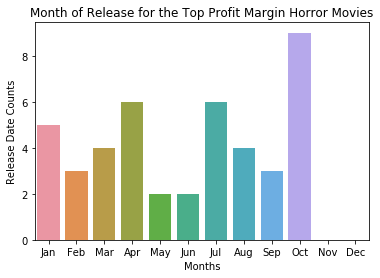

In [54]:
sns.h = sns.barplot(hx, hy)
sns.h.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Horror Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Drama Movies')]

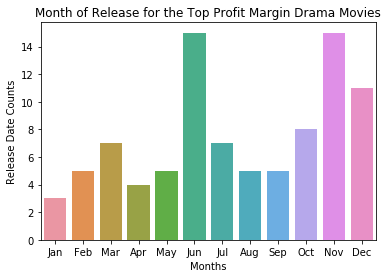

In [55]:
sns.d = sns.barplot(dx, dy)
sns.d.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Drama Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Comedy Movies')]

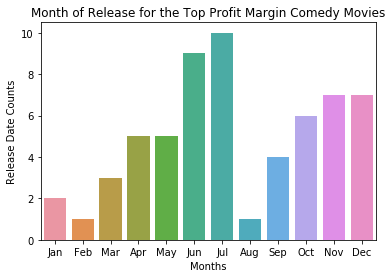

In [56]:
sns.c = sns.barplot(cx, cy)
sns.c.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Comedy Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Thriller Movies')]

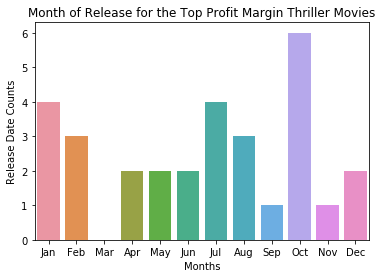

In [57]:
sns.t = sns.barplot(tx, ty)
sns.t.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Thriller Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Action Movies')]

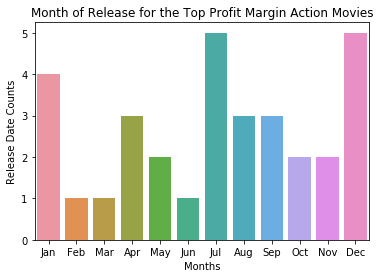

In [58]:
sns.a = sns.barplot(ax, ay)
sns.a.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Action Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Mystery Movies')]

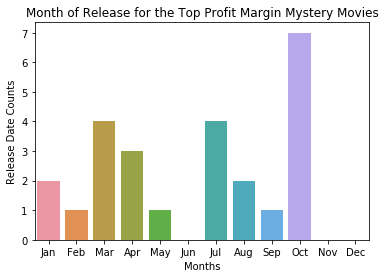

In [59]:
sns.m = sns.barplot(mx, my)
sns.m.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Mystery Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Romance Movies')]

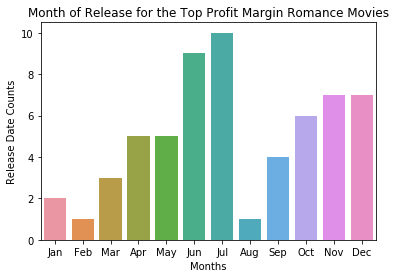

In [60]:
sns.r = sns.barplot(rx, ry)
sns.r.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Romance Movies')

[Text(0, 0.5, 'Release Date Counts'),
 Text(0.5, 0, 'Months'),
 Text(0.5, 1.0, 'Month of Release for the Top Profit Margin Adventure Movies')]

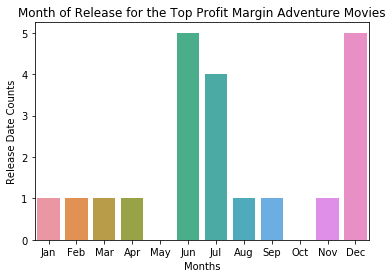

In [61]:
sns.ad = sns.barplot(adx, ady)
sns.ad.set(xlabel = 'Months', ylabel= 'Release Date Counts', title='Month of Release for the Top Profit Margin Adventure Movies')

From the data above, it seems that the most popular release months for Thrillers, Mysteries and Horror movies seem to be roughly similar and the release months for Adventure, Comedy, Romance, Action and Dramas seem to be congruent. For Thrillers, Mysteries and Horror, the major release months of July and October and for the other genres, the main months seem to be Jun, July, November and December.

If you want to increase the odds of a higher profit margin and you selected your genre based on our findings from question 2, you should select the release month of your movie based on the genre as shown below:

My next recommendation would be to accumulate more data to confirm these findings as it is fairly sparse because of the many movies that did not have a genre listed.